In [1]:
import torch

In [2]:
import sys
import os
sys.path.append(os.path.abspath("/home1/smaruj/pytorch_akita/"))

from model_v2_compatible import SeqNN

In [3]:
import ast

In [4]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [5]:
model = SeqNN()
model.load_state_dict(torch.load("/home1/smaruj/pytorch_akita/model_0_v2_finetuned_correctly.pt", map_location=device))
model.eval()

/tmp/SLURM_1759584/ipykernel_1915564/2744654124.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("/home1/smaruj/pytorch_akita/model_0_v2_

SeqNN(
  (stochastic_reverse_complement): StochasticReverseComplement()
  (stochastic_shift): StochasticShift()
  (conv_block_1): ConvBlock(
    (conv): Conv1d(4, 128, kernel_size=(15,), stride=(1,), padding=(7,), bias=False)
    (batch_norm): BatchNorm1d(128, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_tower): ConvTower(
    (conv_tower): Sequential(
      (0): ReLU()
      (1): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): ReLU()
      (5): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (7): MaxPool1d(kernel_size=2, stride=2, paddi

In [6]:
import pandas as pd

In [7]:
FOLD = 0

In [8]:
df = pd.read_csv(f"/scratch1/smaruj/suppressing_CTCFs/fold{FOLD}_with_positions.tsv", sep="\t")

In [9]:
boundary_mask_path = "/scratch1/smaruj/generate_genomic_boundary/boundary_indices.pt"

In [10]:
import sys
sys.path.insert(0, "/home1/smaruj/ledidi")
from ledidi import Ledidi

In [11]:
bin_size = 2048
cropping_applied = 64
padding_bins = 2
padding = padding_bins * bin_size

slice_0_bins = [256]
slice_0_start = (min(slice_0_bins) + cropping_applied - padding_bins) * bin_size
slice_0_end = (max(slice_0_bins) + 1 + cropping_applied + padding_bins) * bin_size

In [ ]:
# df

In [12]:
c = -0.5

In [13]:
import numpy as np

In [14]:
# Helper function to set diagonal elements to a specific value
def set_diag(matrix, value, k):
    # Explicitly set the diagonal to 'value' (in this case, np.nan) for each k
    rows, cols = matrix.shape
    for i in range(rows):
        if 0 <= i + k < cols:
            matrix[i, i + k] = value


def from_upper_triu(vector_repr, matrix_len, num_diags):
    # Ensure vector_repr is a NumPy array (if it's a PyTorch tensor, convert it)
    if isinstance(vector_repr, torch.Tensor):
        vector_repr = vector_repr.detach().flatten().cpu().numpy()  # Flatten and convert to NumPy array

    # Initialize a zero matrix of shape (matrix_len, matrix_len)
    z = np.zeros((matrix_len, matrix_len))

    # Get the indices for the upper triangular matrix
    triu_tup = np.triu_indices(matrix_len, num_diags)

    # Assign the values from the vector_repr to the upper triangular part of the matrix
    z[triu_tup] = vector_repr

    # Set the diagonals specified by num_diags to np.nan
    for i in range(-num_diags + 1, num_diags):
        set_diag(z, np.nan, i)

    # Ensure the matrix is symmetric
    return z + z.T

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

In [16]:
def plot_map(matrix, vmin=-0.6, vmax=0.6, palette="RdBu_r", width=5, height=5):
    fig, axes = plt.subplots(1, 1, figsize=(width, height))

    sns.heatmap(
        matrix,
        vmin=vmin,
        vmax=vmax,
        cbar=False,
        cmap=palette,
        square=True,
        xticklabels=False,
        yticklabels=False,
        ax=axes
    )

    plt.tight_layout()
    plt.show()

In [17]:
def build_ctcf_input_mask(seq_len, ctcf_locs, flanking=15):
    """
    Build a boolean mask tensor indicating CTCF regions + optional flanking bases.

    Args:
        seq_len (int): total length of the sequence (number of positions).
        ctcf_locs (list of tuples): list of (start, end) positions of CTCF sites (0-based, end exclusive).
        flanking (int): number of bases to also mask on each side of the site (default 15).

    Returns:
        torch.BoolTensor: mask of shape (seq_len,) where True means "masked / not editable".
    """
    mask = torch.zeros(seq_len, dtype=torch.bool)
    
    for start, end in ctcf_locs:
        # Apply flanking region, clamp to sequence boundaries
        start_flank = max(0, start - flanking)
        end_flank = min(seq_len, end + flanking)
        
        mask[start_flank:end_flank] = True
    
    return mask

CTCFs suppressing for genome location: chr11:65677312-66988032
Matrix before


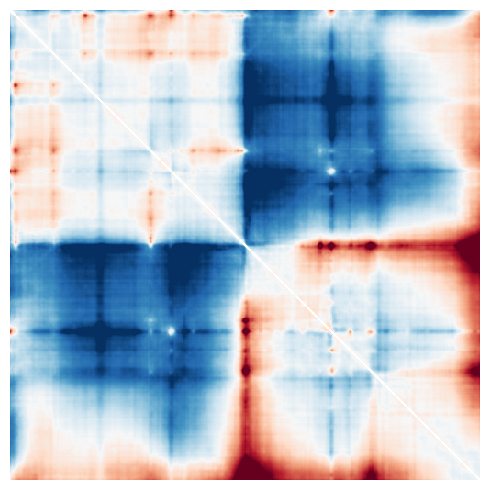

Model in train mode: False
Gradients enabled for weights - slice 0: True
Weights shape - slice 0: torch.Size([1, 4, 2048])
Local loss applied.
iter=I	input_loss=0.0	output_loss=2.302e+04	total_loss=2.302e+04	time=0.0
iter=100	input_loss=282.0	output_loss=1.67e+04	total_loss=1.952e+04	time=15.45
iter=200	input_loss=455.0	output_loss=1.35e+04	total_loss=1.805e+04	time=15.34
iter=300	input_loss=494.0	output_loss=1.302e+04	total_loss=1.796e+04	time=15.34
iter=400	input_loss=497.0	output_loss=1.219e+04	total_loss=1.716e+04	time=15.51
iter=500	input_loss=462.0	output_loss=1.198e+04	total_loss=1.66e+04	time=15.36
iter=600	input_loss=458.0	output_loss=1.18e+04	total_loss=1.638e+04	time=15.53
iter=700	input_loss=469.0	output_loss=1.168e+04	total_loss=1.637e+04	time=15.31
iter=800	input_loss=513.0	output_loss=1.158e+04	total_loss=1.671e+04	time=15.31
iter=900	input_loss=509.0	output_loss=1.149e+04	total_loss=1.658e+04	time=15.29
iter=1000	input_loss=469.0	output_loss=1.112e+04	total_loss=1.581e+

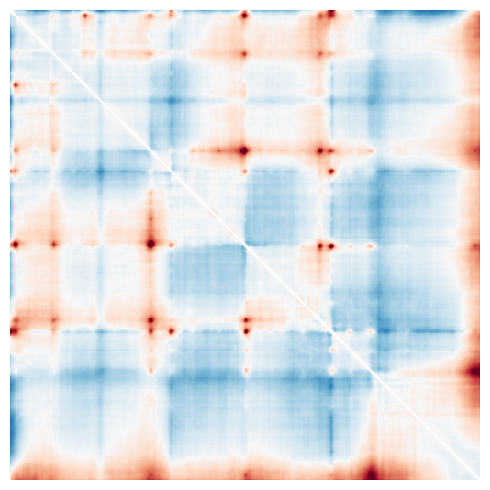

In [18]:
for row in df[1:2].itertuples(index=False):
    chrom, pred_start, pred_end = row.chrom, row.centered_start, row.centered_end
    
    print(f"CTCFs suppressing for genome location: {chrom}:{pred_start}-{pred_end}")
    
    ctcf_locations = ast.literal_eval(row.ctcf_motif_locs)
    
    input_mask = build_ctcf_input_mask(2048, ctcf_locations, 15).to(device=device)
    
    X = torch.load(f"/scratch1/smaruj/suppressing_CTCFs/ohe_X/fold{FOLD}/{chrom}_{pred_start}_{pred_end}_X.pt", weights_only=True, map_location=device)
    target = torch.load(f"/scratch1/smaruj/suppressing_CTCFs/targets/target_{c}/fold{FOLD}/{chrom}_{pred_start}_{pred_end}_target.pt", weights_only=True, map_location=device)
    tower_output_path = f"/scratch1/smaruj/suppressing_CTCFs/tower_outputs/fold{FOLD}/{chrom}_{pred_start}_{pred_end}_tower_out.pt"
    
    model.eval()
    with torch.no_grad():
        pred_before = model(X)
    
    matrix_to_plot_before = from_upper_triu(pred_before[0, 0, :], matrix_len=512, num_diags=2)
    
    print("Matrix before")
    plot_map(matrix_to_plot_before)
    
    wrapper = Ledidi(model, 
                 input_loss=torch.nn.L1Loss(reduction='sum'), 
                 output_loss=torch.nn.L1Loss(reduction='sum'),
                 batch_size=1,
                 l=10.0,
                 max_iter=2000,
                 early_stopping_iter=2000,
                 return_history=True,
                 verbose=True,
                 bin_size=2048,
                 input_mask_slices_0=[256], # mid-bin
                 cropping_applied=64,
                 output_mask_path=boundary_mask_path,
                 use_semifreddo=True,
                 semifreddo_temp_output_path=tower_output_path,
                 punish_ctcf=False,
                 ctcf_meme_path=None,
                 suppressing_mask=input_mask
                 ).cuda()
    
    slice_0_torch = X[:, :, slice_0_start:slice_0_end]
    
    x_bar_slice_0, history = wrapper.fit_transform(X=slice_0_torch, y_bar=target)
    
    X_new = X.clone()
    X_new[:,:,slice_0_start:slice_0_end] = x_bar_slice_0
    
    model.eval()
    with torch.no_grad():
        pred_after = model(X_new)
    
    matrix_to_plot_after = from_upper_triu(pred_after[0, 0, :], matrix_len=512, num_diags=2)
    
    print("Matrix after")
    plot_map(matrix_to_plot_after)
    

<Figure size 800x800 with 0 Axes>

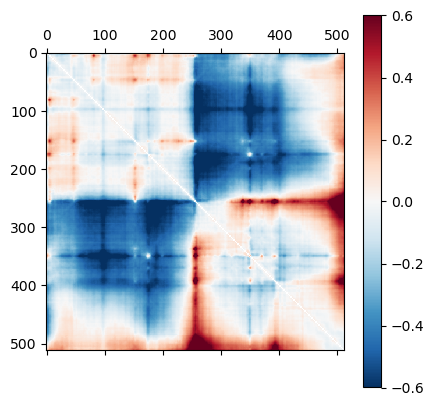

In [27]:
plt.figure(figsize=(8, 8))
plt.matshow(matrix_to_plot_before.astype(np.float16), cmap='RdBu_r', vmin=-0.6, vmax=0.6)
plt.colorbar()
# plt.savefig("map_before.svg", format='svg')
plt.show()

<Figure size 800x800 with 0 Axes>

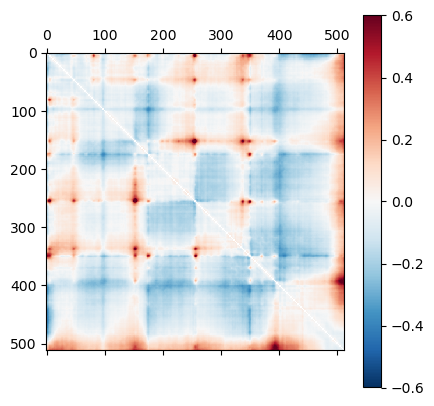

In [28]:
plt.figure(figsize=(8, 8))
plt.matshow(matrix_to_plot_after.astype(np.float16), cmap='RdBu_r', vmin=-0.6, vmax=0.6)
plt.colorbar()
# plt.savefig("map_after.svg", format='svg')
plt.show()

<Figure size 800x800 with 0 Axes>

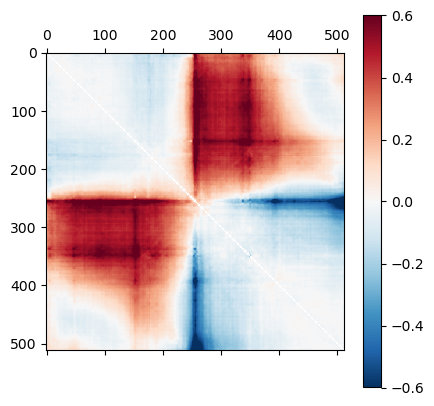

In [29]:
plt.figure(figsize=(8, 8))
plt.matshow(matrix_to_plot_after-matrix_to_plot_before.astype(np.float16), cmap='RdBu_r', vmin=-0.6, vmax=0.6)
plt.colorbar()
# plt.savefig("map_difference.svg", format='svg')
plt.show()

In [31]:
# df

In [32]:
# original DNA seq

path = "/scratch1/smaruj/generate_genomic_boundary/ohe_X/fold0/chr11_65677312_66988032_X.pt"

# Load tensor
ohe_seq = torch.load(path)

/tmp/SLURM_1759584/ipykernel_1915564/3028031261.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ohe_seq = torch.load(path)


In [33]:
model.eval()
with torch.no_grad():
    pred_genomic = model(ohe_seq)

In [34]:
matrix_genomic = from_upper_triu(pred_genomic[0, 0, :], matrix_len=512, num_diags=2)

<Figure size 800x800 with 0 Axes>

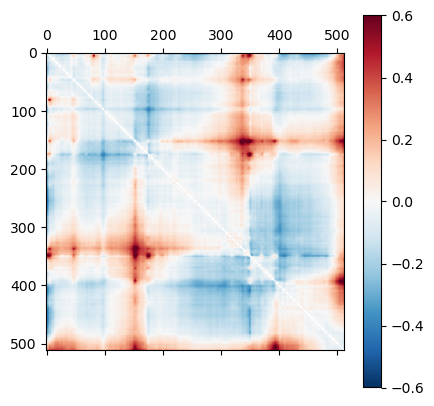

In [35]:
plt.figure(figsize=(8, 8))
plt.matshow(matrix_genomic.astype(np.float16), cmap='RdBu_r', vmin=-0.6, vmax=0.6)
plt.colorbar()
# plt.savefig("map_genomic.svg", format='svg')
plt.show()

In [19]:
for key in history:
    print(key)

input_loss
output_loss
total_loss
gc_content
batch_size
edit_positions


In [20]:
edit_positions = history["edit_positions"][:1950]

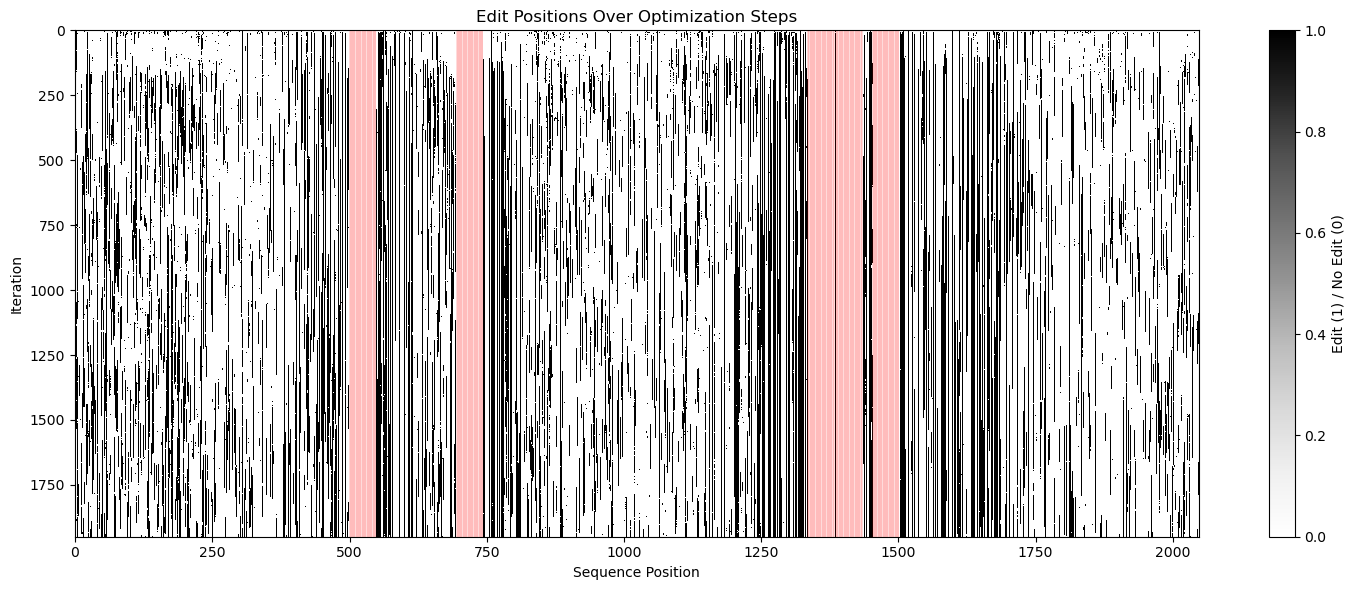

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Convert your list of lists (each of length 2048) to a 2D array
edit_array = np.array(edit_positions)  # shape: (len, 2048)
input_mask_np = input_mask.detach().cpu().numpy()
input_mask = np.array(input_mask_np)  # shape: (2048,), True = no edits allowed

plt.figure(figsize=(15, 6))
plt.imshow(edit_array, aspect='auto', cmap='Greys', interpolation='none')

# Overlay red vertical lines where input_mask is True
for pos in np.where(input_mask)[0]:
    plt.axvline(x=pos, color='red', alpha=0.2, linewidth=0.5)

plt.xlabel('Sequence Position')
plt.ylabel('Iteration')
plt.title('Edit Positions Over Optimization Steps')
plt.colorbar(label='Edit (1) / No Edit (0)')
plt.tight_layout()
plt.show()

In [ ]:
# from pyfaidx import Fasta

In [ ]:
# fasta_file = "/project/fudenber_735/genomes/mm10/mm10.fa"
# genome = Fasta(fasta_file)

In [22]:
CTCF_PWM = "/home1/smaruj/IterativeMutagenesis/MA0139.1.meme"

In [23]:
def read_meme_pwm_as_numpy(filename):
    pwm_list = []  # List to store PWM rows
    
    with open(filename, 'r') as file:
        in_matrix_section = False
        
        for line in file:
            line = line.strip()
            
            # Check if we are reading the PWM matrix
            if line.startswith("letter-probability matrix"):
                in_matrix_section = True  # Start reading matrix data
                continue  # Skip this header line
            
            # If we are in the matrix section, process the rows
            if in_matrix_section and line:
                pwm_row = [float(value) for value in line.split()]  # Parse values
                pwm_list.append(pwm_row)  # Append to the PWM list
            
            # If we encounter a new MOTIF or the end of file, stop matrix reading
            if line.startswith("MOTIF") and in_matrix_section:
                break
    
    # Convert the list to a numpy array
    pwm_array = np.array(pwm_list)
    
    return pwm_array

In [24]:
pwm_CTCF = read_meme_pwm_as_numpy(CTCF_PWM)
pwm_CTCF_tensor = torch.from_numpy(pwm_CTCF.T).float()
motifs_dict = {"CTCF": pwm_CTCF_tensor}

In [25]:
from tangermeme.tools import fimo

In [36]:
320 * 2048

655360

In [39]:
original_hits = fimo.fimo(
    motifs=motifs_dict,
    sequences=X[:, :, 655360:655360+2048],
    threshold=1e-4,
    reverse_complement=True
)[0]

In [40]:
original_hits

,motif_name,motif_idx,sequence_name,start,end,strand,score,p-value
0,CTCF,0,0,514,533,+,13.372330,9.490799e-06
1,CTCF,0,0,709,728,+,8.586131,9.472997e-05
2,CTCF,0,0,1349,1368,+,18.824088,2.888082e-07
3,CTCF,0,0,1400,1419,+,20.039841,1.103763e-07
4,CTCF,0,0,1467,1486,+,17.471144,7.906347e-07


In [41]:
updated_hits = fimo.fimo(
    motifs=motifs_dict,
    sequences=x_bar_slice_0[:, :, 4096:-4096],
    threshold=1e-4,
    reverse_complement=True
)[0]

In [42]:
updated_hits

,motif_name,motif_idx,sequence_name,start,end,strand,score,p-value
0,CTCF,0,0,514,533,+,13.372330,9.490799e-06
1,CTCF,0,0,709,728,+,8.586131,9.472997e-05
2,CTCF,0,0,796,815,+,16.608734,1.350578e-06
3,CTCF,0,0,1349,1368,+,18.824088,2.888082e-07
4,CTCF,0,0,1400,1419,+,20.039841,1.103763e-07
5,CTCF,0,0,1467,1486,+,17.471144,7.906347e-07
6,CTCF,0,0,1580,1599,+,19.051486,2.477173e-07
7,CTCF,0,0,744,763,-,25.030489,1.600711e-10
8,CTCF,0,0,1174,1193,-,20.189036,1.012704e-07
9,CTCF,0,0,1267,1286,-,19.920004,1.200169e-07


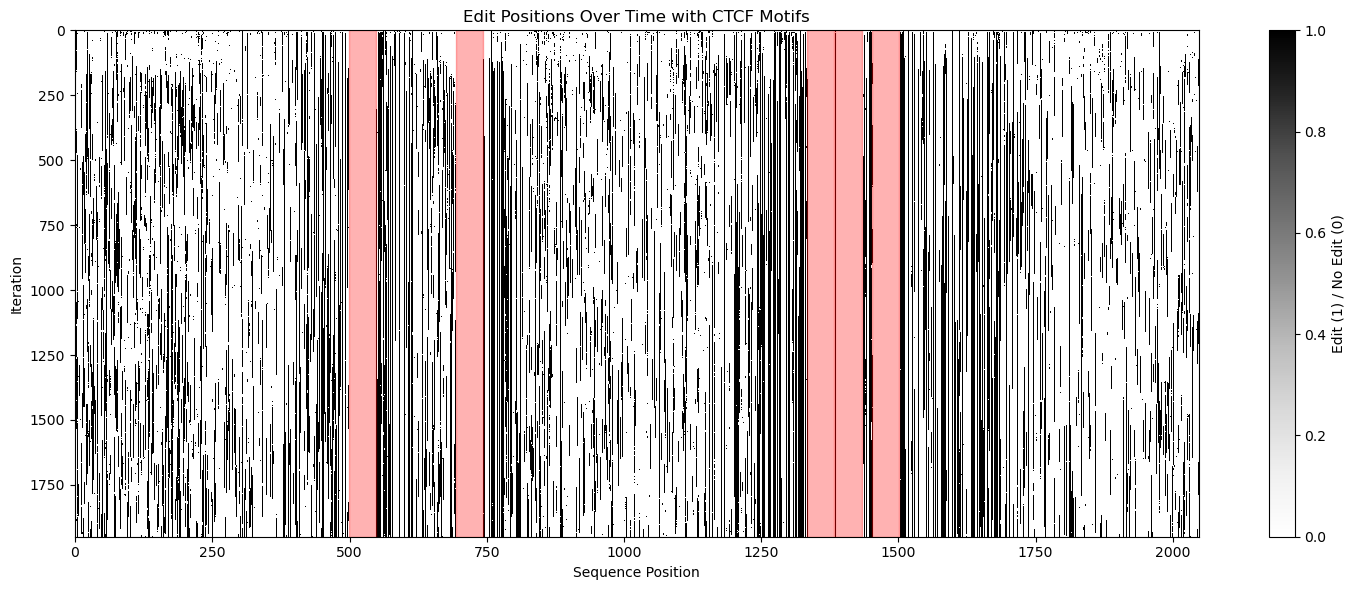

In [44]:
edit_array = np.array(edit_positions)  # shape: (2763, 2048)

plt.figure(figsize=(15, 6))
plt.imshow(edit_array, aspect='auto', cmap='Greys', interpolation='none')

plotting_flank = 15

# Plot vertical shaded regions for CTCF motif positions
for _, row in original_hits.iterrows():
    start = row['start']
    end = row['end']
    plt.axvspan(start-plotting_flank, end+plotting_flank , color='red', alpha=0.3)

plt.xlabel('Sequence Position')
plt.ylabel('Iteration')
plt.title('Edit Positions Over Time with CTCF Motifs')
plt.colorbar(label='Edit (1) / No Edit (0)')

plt.tight_layout()
plt.show()

In [45]:
# Convert to sets of (start, end) for comparison
original_coords = set(zip(original_hits["start"], original_hits["end"]))
updated_coords = set(zip(updated_hits["start"], updated_hits["end"]))

# Identify new hits in updated_hits
new_coords = updated_coords - original_coords
new_hits = updated_hits[updated_hits.apply(lambda r: (r["start"], r["end"]) in new_coords, axis=1)]

In [50]:
new_hits.sort_values(by="start")

,motif_name,motif_idx,sequence_name,start,end,strand,score,p-value
7,CTCF,0,0,744,763,-,25.030489,1.600711e-10
2,CTCF,0,0,796,815,+,16.608734,1.350578e-06
8,CTCF,0,0,1174,1193,-,20.189036,1.012704e-07
9,CTCF,0,0,1267,1286,-,19.920004,1.200169e-07
10,CTCF,0,0,1571,1590,-,8.995685,7.970190e-05
6,CTCF,0,0,1580,1599,+,19.051486,2.477173e-07


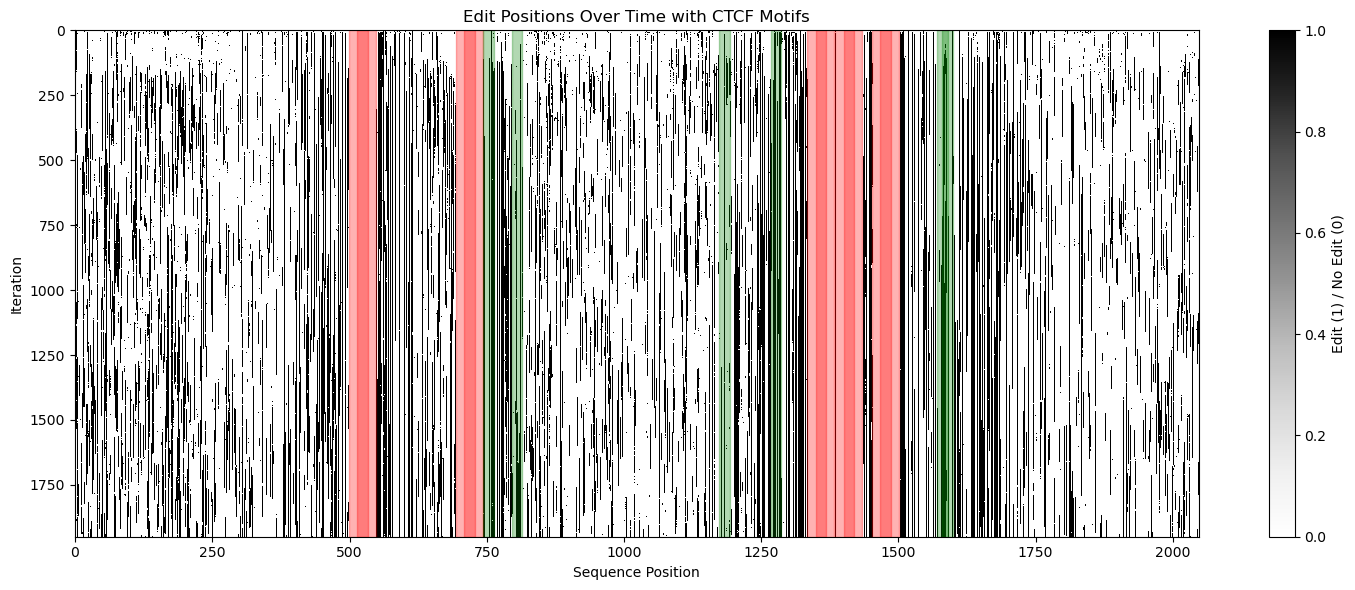

In [49]:
# Plot the edit array
plt.figure(figsize=(15, 6))
plt.imshow(edit_array, aspect="auto", cmap="Greys", interpolation="none")

plotting_flank = 15

# Plot red spans = original hits
for _, row in original_hits.iterrows():
    start, end = row["start"], row["end"]
    plt.axvspan(start - plotting_flank, end + plotting_flank, color="red", alpha=0.3)

for _, row in original_hits.iterrows():
    start, end = row["start"], row["end"]
    plt.axvspan(start, end, color="red", alpha=0.3)

# Plot green spans = new hits only in updated_hits
for _, row in new_hits.iterrows():
    start, end = row["start"], row["end"]
    plt.axvspan(start, end, color="green", alpha=0.3)

plt.xlabel("Sequence Position")
plt.ylabel("Iteration")
plt.title("Edit Positions Over Time with CTCF Motifs")
plt.colorbar(label="Edit (1) / No Edit (0)")

plt.tight_layout()
plt.show()